In [1]:
import pandas as pd

# Load predictions
df = pd.read_csv('C:/Users/ELITE/Documents/AGROALERT/data_processed/predictions.csv')

# Dashboard summary
print("=== AgroAlert Ghana Dashboard Summary ===\n")
print("Communities monitored:", df['community'].nunique())
print("Date range:", df['date'].min(), "to", df['date'].max())
print("\nCurrent drought risk by community:")
latest = df.groupby('community')['ensemble_score'].max().sort_values(ascending=False)
for community, score in latest.items():
    status = "🔴 HIGH RISK" if score >= 0.75 else "🟡 MEDIUM" if score >= 0.5 else "🟢 LOW"
    print(f"  {community}: {score:.2f} — {status}")

print(f"\nTotal alerts triggered: {df['alert_triggered'].sum()}")

=== AgroAlert Ghana Dashboard Summary ===

Communities monitored: 5
Date range: 2022-01-02 to 2023-12-31

Current drought risk by community:
  Ho: 0.88 — 🔴 HIGH RISK
  Techiman: 0.88 — 🔴 HIGH RISK
  Kumasi: 0.88 — 🔴 HIGH RISK
  Tamale: 0.53 — 🟡 MEDIUM
  Bolgatanga: 0.44 — 🟢 LOW

Total alerts triggered: 8


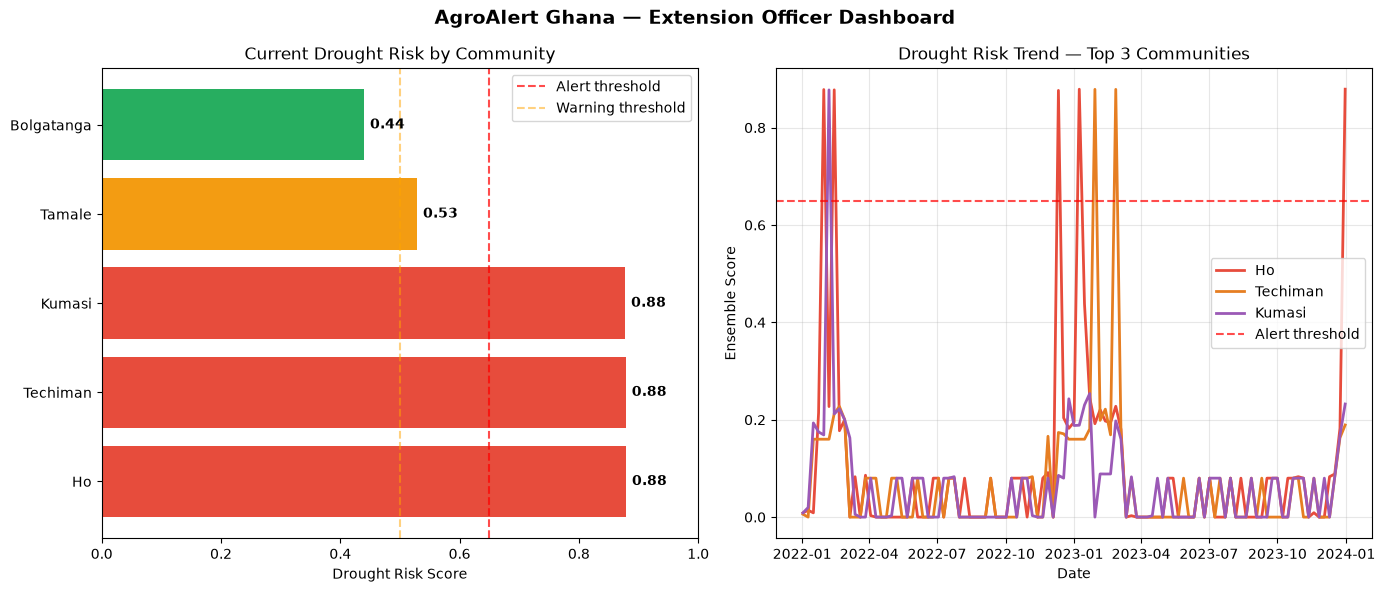

Dashboard saved!


In [2]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# Get latest score per community
latest_scores = df.groupby('community')['ensemble_score'].max().sort_values(ascending=False)

# Colors based on risk level
colors = []
for score in latest_scores.values:
    if score >= 0.75:
        colors.append('#e74c3c')  # red
    elif score >= 0.5:
        colors.append('#f39c12')  # orange
    else:
        colors.append('#27ae60')  # green

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('AgroAlert Ghana — Extension Officer Dashboard', 
             fontsize=14, fontweight='bold')

# Chart 1: Risk scores by community
bars = axes[0].barh(latest_scores.index, latest_scores.values, color=colors)
axes[0].axvline(x=0.65, color='red', linestyle='--', alpha=0.7, label='Alert threshold')
axes[0].axvline(x=0.5, color='orange', linestyle='--', alpha=0.5, label='Warning threshold')
axes[0].set_xlabel('Drought Risk Score')
axes[0].set_title('Current Drought Risk by Community')
axes[0].set_xlim(0, 1)
axes[0].legend()

for bar, score in zip(bars, latest_scores.values):
    axes[0].text(score + 0.01, bar.get_y() + bar.get_height()/2,
                f'{score:.2f}', va='center', fontweight='bold')

# Chart 2: Risk score over time for top 3 communities
top_communities = ['Ho', 'Techiman', 'Kumasi']
colors_line = ['#e74c3c', '#e67e22', '#9b59b6']

for i, community in enumerate(top_communities):
    df_c = df[df['community'] == community].copy()
    df_c['date'] = pd.to_datetime(df_c['date'])
    axes[1].plot(df_c['date'], df_c['ensemble_score'], 
                label=community, color=colors_line[i], linewidth=2)

axes[1].axhline(y=0.65, color='red', linestyle='--', alpha=0.7, label='Alert threshold')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Ensemble Score')
axes[1].set_title('Drought Risk Trend — Top 3 Communities')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('C:/Users/ELITE/Documents/AGROALERT/data_processed/dashboard.png', 
            dpi=150, bbox_inches='tight')
plt.show()
print("Dashboard saved!")